# This Notebook

Takes the Medical Transcriptions dataset. Makes use of the "transcription" and "medical_specialty" columns, and makes a classifier to predict speciality.

Settings use:
- Preprocessing:
    - ✅ Normalization (Lowercasing, Normalizing Unicode, Tons of Regex)
    - ✅ Tokenization (Mandatory)
    - ❌ Stopword removal (Not recommended cause it discards information), can be enabled.
    - ✅ Lemmatization (we are interested in proper nouns, so rest can be normalized)
- N-Gram: (1,2) is used. Can be experimented with using other settings.
- Classifier: SVM (LinearSVC) used. Can be experimented with using other classifiers.

In [54]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
import os
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from typing import Callable, Any
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [55]:
dataset_path = kagglehub.dataset_download('tboyle10/medicaltranscriptions')

medical_transcriptions = pd.read_csv(os.path.join(dataset_path, 'mtsamples.csv'))

medical_transcriptions

100%|██████████| 4.85M/4.85M [00:01<00:00, 2.83MB/s]

Extracting files...


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."
...,...,...,...,...,...,...
4994,4994,Patient having severe sinusitis about two to ...,Allergy / Immunology,Chronic Sinusitis,"HISTORY:, I had the pleasure of meeting and e...",NaN
4995,4995,This is a 14-month-old baby boy Caucasian who...,Allergy / Immunology,Kawasaki Disease - Discharge Summary,"ADMITTING DIAGNOSIS: , Kawasaki disease.,DISCH...","allergy / immunology, mucous membranes, conjun..."
4996,4996,A female for a complete physical and follow u...,Allergy / Immunology,Followup on Asthma,"SUBJECTIVE: , This is a 42-year-old white fema...",NaN
4997,4997,Mother states he has been wheezing and coughing.,Allergy / Immunology,Asthma in a 5-year-old,"CHIEF COMPLAINT: , This 5-year-old male presen...",NaN


In [56]:
def consolidate_speciality(base_df: pd.DataFrame, classes: list[str], new_speciality: str):
    filtered_df = base_df[base_df['medical_specialty'].str.strip().isin(classes)].copy()
    filtered_df['specialty'] = new_speciality
    return filtered_df

def trim_down(base_df: pd.DataFrame, count: int, shuffle: bool = True):
    if shuffle:
        return base_df.sample(n = count, random_state = 42).reset_index(drop = True).copy()
    else:
        return base_df[:count].copy()

**Note**: Looks like it's a bad idea to consolidate multiple specialities to reduce class count. It creates too many overlaps and gives the classifier a hard time. Better to work with a small subset of specialities rather. Carefully increase the class count and look at the metrics. Should we make an "others" class?

In [57]:
# regrouped_df = pd.concat([
#     consolidate_speciality(
#         medical_transcriptions,
#         ['General Medicine', 'Hematology - Oncology', 'Endocrinology', 'Rheumatology', 'Allergy / Immunology', 'Hospice - Palliative Care'],
#         'General Internal Medicine & Systemic Care'
#     ),

#     consolidate_speciality(
#         medical_transcriptions,
#         ['Gastroenterology', 'Urology', 'Nephrology'],
#         'Visceral, Renal & Urinary Medicine'
#     ),

#     consolidate_speciality(
#         medical_transcriptions,
#         ['Orthopedic', 'Pain Management', 'Podiatry', 'Physical Medicine - Rehab'],
#         'Musculoskeletal & Rehabilitation'
#     ),

#     consolidate_speciality(
#         medical_transcriptions,
#         ['Cosmetic / Plastic Surgery', 'Bariatrics'],
#         'Advanced Surgical & Reconstructive Care'
#     ),

#     trim_down(
#         consolidate_speciality(
#             medical_transcriptions,
#             ['Surgery'],
#             'Advanced Surgical & Reconstructive Care'
#         ),
#         count = 350
#     ),

#     consolidate_speciality(
#         medical_transcriptions,
#         ['Neurology', 'Neurosurgery', 'Psychiatry / Psychology', 'Sleep Medicine'],
#         'Brain, Behavior & Sleep Sciences'
#     ),

#     consolidate_speciality(
#         medical_transcriptions,
#         ['Cardiovascular / Pulmonary'],
#         'Cardiovascular & Pulmonary Medicine'
#     ),

#     consolidate_speciality(
#         medical_transcriptions,
#         ['Radiology', 'Lab Medicine - Pathology'],
#         'Diagnostics, Imaging & Pathology'
#     ),

#     consolidate_speciality(
#         medical_transcriptions,
#         ['ENT - Otolaryngology', 'Ophthalmology', 'Dermatology', 'Dentistry'],
#         'Head, Neck & Sensory Organs'
#     ),

#     consolidate_speciality(
#         medical_transcriptions,
#         ['Obstetrics / Gynecology', 'Pediatrics - Neonatal'],
#         'Maternal, Neonatal & Pediatric Care'
#     )
# ], ignore_index = True, sort = False)


regrouped_df = pd.concat([
    # K1
    consolidate_speciality(
        medical_transcriptions,
        ['Gastroenterology'],
        'Gastroenterology'
    ),


    # K1
    consolidate_speciality(
        medical_transcriptions,
        ['Neurology'],
        'Neurology'
    ),

    # K1
    trim_down(
        consolidate_speciality(
            medical_transcriptions,
            ['Cardiovascular / Pulmonary'],
            'Cardiovascular / Pulmonary'
        ),
        count = 240
    ),

    # K1
    consolidate_speciality(
        medical_transcriptions,
        ['Ophthalmology'],
        'Ophthalmology'
    ),

    # K1
    consolidate_speciality(
        medical_transcriptions,
        ['Obstetrics / Gynecology'],
        'Obstetrics / Gynecology'
    )
], ignore_index = True, sort = False)

regrouped_df

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords,specialty
0,3455,This is a pleasant 50-year-old female who has...,Gastroenterology,Wound Check - Status Post APR,"HISTORY OF PRESENT ILLNESS:, Ms. Connor is a ...","gastroenterology, perineal wound, wound infect...",Gastroenterology
1,3456,Upper endoscopy with foreign body removal (Pe...,Gastroenterology,Upper Endoscopy - Foreign Body Removal,"PROCEDURE:, Upper endoscopy with foreign body ...","gastroenterology, upper endoscopy, endoscopy, ...",Gastroenterology
2,3458,Umbilical hernia repair. A standard curviline...,Gastroenterology,Umbilical Hernia Repair - 1,"PROCEDURE PERFORMED: , Umbilical hernia repair...","gastroenterology, fascial defect, umbilical he...",Gastroenterology
3,3462,Viral gastroenteritis. Patient complaining o...,Gastroenterology,Viral Gastroenteritis,"HISTORY OF PRESENT ILLNESS: , Patient is a 40-...","gastroenterology, nausea, vomiting, viral gast...",Gastroenterology
4,3463,Upper endoscopy with removal of food impaction.,Gastroenterology,Upper Endoscopy,"PROCEDURE:, Upper endoscopy with removal of f...","gastroenterology, dysphagia, removal of food i...",Gastroenterology
...,...,...,...,...,...,...,...
931,2659,"Diagnostic mammogram, full-field digital, ult...",Obstetrics / Gynecology,Breast Ultrasound & Biopsy,"EXAM: ,Bilateral diagnostic mammogram, left b...","obstetrics / gynecology, mammotome core biopsy...",Obstetrics / Gynecology
932,2660,"Abdominosacrocolpopexy, enterocele repair, cy...",Obstetrics / Gynecology,Abdominosacrocolpopexy,"PREOPERATIVE DIAGNOSES:,1. Vault prolapse.,2....","obstetrics / gynecology, enterocele repair, cy...",Obstetrics / Gynecology
933,2663,"BPP of Gravida 1, para 0 at 33 weeks 5 days b...",Obstetrics / Gynecology,Biophysical Profile,"CLINICAL HISTORY:, Gravida 1, para 0 at 33 we...","obstetrics / gynecology, biophysical profile, ...",Obstetrics / Gynecology
934,2664,Desires permanent sterilization. Laparoscopi...,Obstetrics / Gynecology,Bilateral Tubal Occlusion - Laparoscopic,"PREOPERATIVE DIAGNOSIS: , Desires permanent st...","obstetrics / gynecology, laparoscopic bilatera...",Obstetrics / Gynecology


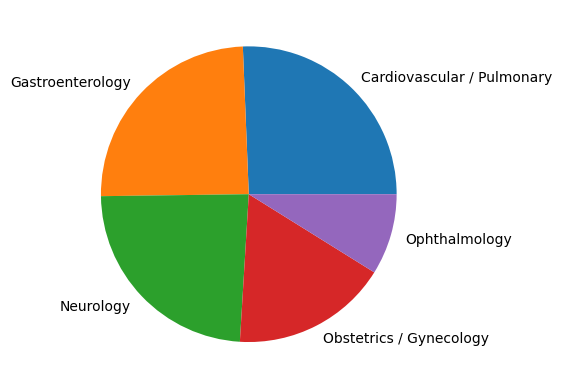

In [59]:
speciality_dist = regrouped_df['specialty'].value_counts().to_dict()

speciality_names = list(speciality_dist.keys())
speciality_counts = [speciality_dist[s] for s in speciality_names]

fig, ax = plt.subplots()
ax.pie(speciality_counts, labels = speciality_names)
plt.show()

In [60]:
regrouped_df['label'] = regrouped_df['specialty'].map(lambda s : speciality_names.index(s))

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_medical_transcript(text: str) -> str:

    text = unidecode(text)

    # 1. Standardize case and strip line breaks/tabs
    text = text.lower()
    text = re.sub(r'[\r\n\t]', ' ', text)
    
    # 2. Remove universal formatting noise (duplicate commas, list numbers like "1. ", "2. ")
    text = re.sub(r',\s*,', ' ', text)
    text = re.sub(r'\b\d+\.\s+', ' ', text)

    # 3. Standardize symbols that carry universal clinical meaning
    text = text.replace('%', ' percent ')
    
    # 4. Abstract ALL numerical values (weights, dosages, dimensions, vitals)
    # This prevents your TF-IDF vocabulary from bloating with thousands of unique numbers
    text = re.sub(r'\b\d+(?:\.\d+)?\b', ' [num] ', text)

    # 5. Universal Punctuation Stripper
    # Keeps only lowercase letters, numbers, spaces, and our placeholder brackets.
    # This naturally handles hyphens (e.g., "beta-blocker" -> "beta blocker", "2-d" -> "2 d")
    text = re.sub(r'[^a-z0-9\[\]\s]', ' ', text)
    
    # 6. Collapse duplicate spaces
    text = " ".join(text.split())

    return text

def remove_stopwords(tokens: list[str]) -> list[str]:
    return list(
        filter(
            lambda t : t not in stop_words and len(t) > 1,
            tokens
        )
    )

def lemmatize(tokens: list[str]) -> list[str]:
    return list(
        map(
            lambda t: lemmatizer.lemmatize(t),
            tokens
        )
    )

class TextPreprocessor:
    transformations: list[Callable]

    def __init__(self) -> None:
        self.transformations = []

    def add(self, tfomer: Callable):
        self.transformations.append(tfomer)
        return self

    def __call__(self, sample: str) -> Any:
        for tform in self.transformations:
            sample = tform(sample)
        return sample

In [61]:
preprocessor = TextPreprocessor() \
    .add(preprocess_medical_transcript) \
    .add(nltk.word_tokenize) \
    .add(lemmatize)
    # .add(remove_stopwords) \

vectorizer_tfidf = TfidfVectorizer(
    lowercase     = False, # already handled
    tokenizer     = preprocessor,

    stop_words    = None, # again, already handled
    ngram_range   = (1, 2),
    token_pattern = None, # pyright: ignore[reportArgumentType]

    min_df       = 2,
    max_df       = 0.95,
    sublinear_tf = True
)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(regrouped_df['transcription'], regrouped_df['label'], test_size = 0.2, random_state = 42, stratify = regrouped_df['label'])

In [63]:
train_tfidf = vectorizer_tfidf.fit_transform(X_train.values.astype('U'))
test_tfidf  = vectorizer_tfidf.transform(X_test.values.astype('U'))

In [64]:
clf_svc = LinearSVC(class_weight = 'balanced', random_state = 42)
clf_svc.fit(X = train_tfidf, y = y_train.to_list())

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [65]:
test_pred = clf_svc.predict(X = test_tfidf)
print(classification_report(y_test.to_list(), test_pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91        48
           1       0.90      0.96      0.93        46
           2       0.89      0.93      0.91        45
           3       1.00      0.94      0.97        32
           4       1.00      0.94      0.97        17

    accuracy                           0.93       188
   macro avg       0.95      0.93      0.94       188
weighted avg       0.93      0.93      0.93       188



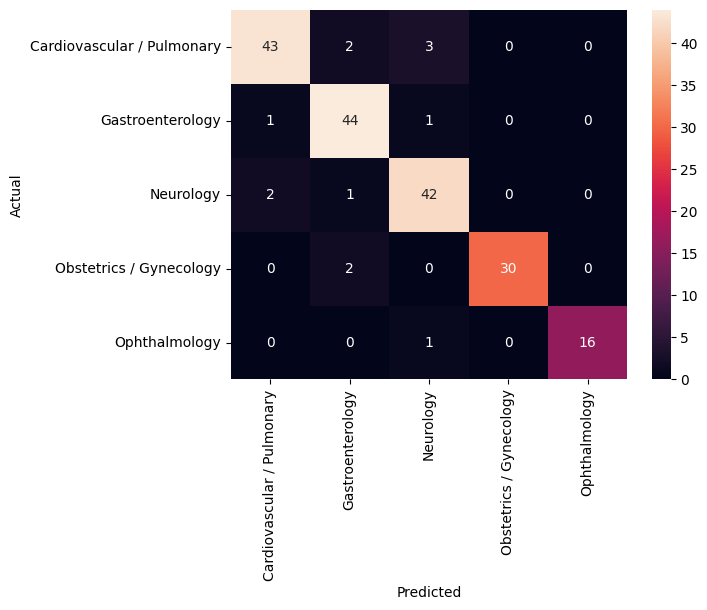

In [66]:
conf_mat = confusion_matrix(y_true = y_test.to_numpy(), y_pred = test_pred)
ticklabels = speciality_names
sns.heatmap(conf_mat, annot = True, fmt = 'd', xticklabels = ticklabels, yticklabels = ticklabels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [67]:
ipred = clf_svc.predict(X = vectorizer_tfidf.transform(['Daily epigastric burning, postprandial bloating, early satiety. No weight loss, dysphagia, or bleeding. Prior negative H. pylori breath test.']))
speciality_names[ipred[0]]

'Gastroenterology'

In [68]:
ipred = clf_svc.predict(X = vectorizer_tfidf.transform(['Reports intermenstrual spotting and heavy flow every 24-28 days lasting 7-9 days. No pelvic pain, dyspareunia, or postcoital bleeding. LMP 05/10/2026.']))
speciality_names[ipred[0]]

'Obstetrics / Gynecology'